# **Model Explainability**

Machine learning models are often regarded as black-box systems because their decision-making processes are not readily interpretable by humans. In healthcare applications, understanding how a model arrives at its predictions is essential for promoting transparency, building clinician trust, and supporting informed decision-making. Explainability techniques provide valuable insight into the contribution of individual predictor variables, allowing researchers to identify the factors that most strongly influence model predictions.

This notebook applies both SHAP (SHapley Additive exPlanations) and LIME (Local Interpretable Model-agnostic Explanations) to explain the predictions of the developed coronary heart disease classification models. SHAP is employed to provide both global and local explanations by quantifying the contribution of each feature to the prediction process, while LIME is used to generate interpretable local explanations for individual patient predictions. Together, these techniques improve the transparency and interpretability of the developed machine learning models.

### **Library Imports**

The required Python libraries are imported to facilitate data loading, model retrieval, visualization, and explainability analysis. These libraries support the loading of the previously developed machine learning models and datasets, as well as the implementation of SHAP and LIME techniques to improve the transparency and interpretability of the developed coronary heart disease prediction models.

In [3]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd
import numpy as np

# Model persistence
import joblib

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model explainability
import shap
import lime
import lime.lime_tabular



### **Data Ingestion**

The previously prepared training and testing datasets are loaded to support the explainability analyses. The training dataset serves as the reference data for local explanation methods such as LIME, while the testing dataset is used to generate both global and local explanations of the developed machine learning models. Loading both the original and scaled datasets ensures that each model receives the appropriate input format used during its development and evaluation, thereby maintaining consistency throughout the explainability process.

In [4]:
# Load the original training and testing feature datasets
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

# Load the scaled training and testing feature datasets
X_train_scaled = pd.read_csv(
    "../data/processed/X_train_scaled.csv"
)

X_test_scaled = pd.read_csv(
    "../data/processed/X_test_scaled.csv"
)

# Load the training and testing target variables
y_train = pd.read_csv(
    "../data/processed/y_train.csv"
).squeeze()

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

# Ensure target variables are one-dimensional
y_train = np.asarray(y_train).ravel()
y_test = np.asarray(y_test).ravel()

print("Training and testing datasets loaded successfully.")

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Training and testing datasets loaded successfully.
X_train shape: (3392, 15)
X_test shape: (848, 15)
X_train_scaled shape: (3392, 15)
X_test_scaled shape: (848, 15)
y_train shape: (3392,)
y_test shape: (848,)


### **Model Ingestion**

The final tuned machine learning models are loaded to facilitate the explainability analyses. These models were selected because they represent the optimized versions obtained after hyperparameter tuning and demonstrated competitive predictive performance during the comparative evaluation. Loading the final models ensures that the explainability techniques provide meaningful insights into the decision-making process of the models recommended for coronary heart disease prediction.

In [5]:
# Load the final tuned machine learning models
logistic_regression = joblib.load(
    "../models/logistic_regression_tuned.pkl"
)

random_forest = joblib.load(
    "../models/random_forest_tuned.pkl"
)

xgboost = joblib.load(
    "../models/xgboost_tuned.pkl"
)

print("Final tuned models loaded successfully.\n")

print(f"Logistic Regression: {type(logistic_regression).__name__}")
print(f"Random Forest: {type(random_forest).__name__}")
print(f"XGBoost: {type(xgboost).__name__}")

Final tuned models loaded successfully.

Logistic Regression: Pipeline
Random Forest: Pipeline
XGBoost: Pipeline


In [7]:
# Inspect the steps in each pipeline
print("Logistic Regression Pipeline:")
print(logistic_regression.named_steps)

print("\nRandom Forest Pipeline:")
print(random_forest.named_steps)

print("\nXGBoost Pipeline:")
print(xgboost.named_steps)

Logistic Regression Pipeline:
{'scaler': StandardScaler(), 'resampler': SMOTEENN(random_state=42), 'model': LogisticRegression(C=0.01, max_iter=2000, random_state=42, solver='saga')}

Random Forest Pipeline:
{'resampler': SMOTEENN(random_state=42), 'model': RandomForestClassifier(max_depth=5, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)}

XGBoost Pipeline:
{'resampler': SMOTEENN(random_state=42), 'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=No

### **Preparation for Explainability Analysis**

The underlying classifiers are extracted from their respective pipelines to ensure compatibility with the selected explainability techniques. Although the final models were stored as pipelines containing preprocessing and resampling steps, SHAP requires direct access to the fitted estimators when specialised explainers are applied. The appropriate testing datasets are also assigned to each model according to the preprocessing procedures used during model development. The scaled testing dataset is assigned to Logistic Regression, while the original unscaled testing dataset is retained for the Random Forest and XGBoost models.

In [8]:
# Extract the fitted estimators from the model pipelines
logistic_model = logistic_regression.named_steps["model"]
random_forest_model = random_forest.named_steps["model"]
xgboost_model = xgboost.named_steps["model"]

# Assign the appropriate testing dataset to each model
X_explain_logistic = X_test_scaled.copy()
X_explain_random_forest = X_test.copy()
X_explain_xgboost = X_test.copy()

# Preserve the original feature names
feature_names = X_test.columns.tolist()

print("Underlying estimators extracted successfully.\n")

print(f"Logistic Regression estimator: {type(logistic_model).__name__}")
print(f"Random Forest estimator: {type(random_forest_model).__name__}")
print(f"XGBoost estimator: {type(xgboost_model).__name__}")

print("\nExplainability dataset dimensions:")
print(f"Logistic Regression data: {X_explain_logistic.shape}")
print(f"Random Forest data: {X_explain_random_forest.shape}")
print(f"XGBoost data: {X_explain_xgboost.shape}")

Underlying estimators extracted successfully.

Logistic Regression estimator: LogisticRegression
Random Forest estimator: RandomForestClassifier
XGBoost estimator: XGBClassifier

Explainability dataset dimensions:
Logistic Regression data: (848, 15)
Random Forest data: (848, 15)
XGBoost data: (848, 15)


### **SHAP Explainability Analysis**

SHAP (SHapley Additive exPlanations) is employed to interpret the predictions of the developed machine learning models by quantifying the contribution of each predictor variable to the model's output. Based on cooperative game theory, SHAP assigns an importance value to every feature, enabling both global and local interpretation of model predictions. In this study, SHAP is applied to identify the most influential clinical and demographic factors associated with coronary heart disease prediction, thereby improving the transparency and interpretability of the developed machine learning models.

#### **SHAP Explainer Helper Function**

A reusable helper function is defined to create the appropriate SHAP explainer for each machine learning model. Tree-based models, including Random Forest and XGBoost, are interpreted using `TreeExplainer`, while Logistic Regression is interpreted using `LinearExplainer`. This approach reduces code repetition and ensures that each model is analysed using an explainer suited to its underlying learning algorithm.

In [9]:
# Create the appropriate SHAP explainer for each model
def create_shap_explainer(model, background_data, model_type):
    """
    Create a SHAP explainer based on the model architecture.

    Parameters
    ----------
    model : fitted estimator
        The trained machine learning model to be explained.

    background_data : pandas.DataFrame
        Reference dataset used by the SHAP explainer.

    model_type : str
        Type of model. Accepted values are:
        "linear" or "tree".

    Returns
    -------
    shap.Explainer
        A fitted SHAP explainer.
    """

    model_type = model_type.lower()

    if model_type == "linear":
        explainer = shap.LinearExplainer(
            model,
            background_data
        )

    elif model_type == "tree":
        explainer = shap.TreeExplainer(
            model
        )

    else:
        raise ValueError(
            "Invalid model_type. Use either 'linear' or 'tree'."
        )

    return explainer


print("SHAP explainer helper function created successfully.")

SHAP explainer helper function created successfully.


#### **SHAP Explainer Initialisation**

The helper function is applied to initialise separate SHAP explainers for the tuned Logistic Regression, Random Forest, and XGBoost models. A representative sample of the testing data is used as background data for Logistic Regression to improve computational efficiency, while the tree-based explainers are created directly from their fitted estimators.

In [10]:
# Select representative background data for Logistic Regression
background_logistic = shap.sample(
    X_explain_logistic,
    100,
    random_state=42
)

# Initialise the SHAP explainers
logistic_explainer = create_shap_explainer(
    model=logistic_model,
    background_data=background_logistic,
    model_type="linear"
)

random_forest_explainer = create_shap_explainer(
    model=random_forest_model,
    background_data=X_explain_random_forest,
    model_type="tree"
)

xgboost_explainer = create_shap_explainer(
    model=xgboost_model,
    background_data=X_explain_xgboost,
    model_type="tree"
)

print("SHAP explainers initialised successfully.")

print(f"\nLogistic Regression explainer: "
      f"{type(logistic_explainer).__name__}")

print(f"Random Forest explainer: "
      f"{type(random_forest_explainer).__name__}")

print(f"XGBoost explainer: "
      f"{type(xgboost_explainer).__name__}")

SHAP explainers initialised successfully.

Logistic Regression explainer: LinearExplainer
Random Forest explainer: TreeExplainer
XGBoost explainer: TreeExplainer


#### **Computation of SHAP Values**

The initialized SHAP explainers are applied to the corresponding testing datasets to calculate feature-level contribution values for each prediction. These SHAP values quantify the direction and magnitude of each predictor’s influence on the estimated probability of coronary heart disease. The resulting explanation objects are retained for subsequent global and local interpretation.

In [11]:
# Compute SHAP values for the tuned models
logistic_shap_values = logistic_explainer(
    X_explain_logistic
)

random_forest_shap_values = random_forest_explainer(
    X_explain_random_forest
)

xgboost_shap_values = xgboost_explainer(
    X_explain_xgboost
)

print("SHAP values computed successfully.\n")

print(
    f"Logistic Regression SHAP shape: "
    f"{logistic_shap_values.values.shape}"
)

print(
    f"Random Forest SHAP shape: "
    f"{random_forest_shap_values.values.shape}"
)

print(
    f"XGBoost SHAP shape: "
    f"{xgboost_shap_values.values.shape}"
)

SHAP values computed successfully.

Logistic Regression SHAP shape: (848, 15)
Random Forest SHAP shape: (848, 15, 2)
XGBoost SHAP shape: (848, 15)


#### **SHAP Summary Plot for the Tuned XGBoost Model**

A SHAP summary plot is generated for the tuned XGBoost model to provide a global explanation of its prediction behaviour. The plot ranks predictor variables according to their overall contribution to the model while simultaneously illustrating the direction and magnitude of each feature's influence across all observations. Features positioned higher in the plot exert greater influence on the prediction of coronary heart disease.

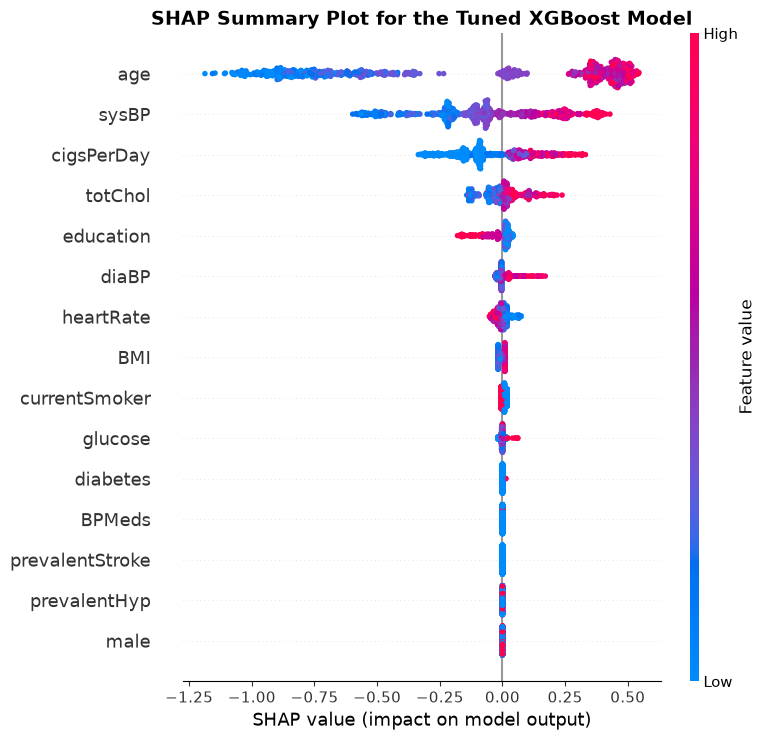

In [12]:
# Generate the SHAP summary plot for the tuned XGBoost model
plt.figure(figsize=(10, 8))

shap.summary_plot(
    xgboost_shap_values,
    X_explain_xgboost,
    show=False
)

plt.title(
    "SHAP Summary Plot for the Tuned XGBoost Model",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


The SHAP summary plot provides a global explanation of the tuned XGBoost model by ranking predictor variables according to their overall contribution to coronary heart disease prediction. The variables are arranged from the most influential at the top to the least influential at the bottom based on their average absolute SHAP values.

`age` emerged as the most influential predictor in the tuned XGBoost model. Higher values of `age` generally increased the predicted probability of coronary heart disease, whereas lower values were associated with a reduced predicted risk. This indicates that `age` was the primary factor driving the model's predictions.

`sysBP` and `cigsPerDay` were also identified as major contributors to the prediction process. Higher values of these variables generally increased the likelihood of coronary heart disease, while lower values contributed towards lower predicted risk.

`totChol`, `education`, and `diaBP` demonstrated moderate influence on the model output. Although their contributions varied among individual observations, these variables still played meaningful roles in the model's prediction process.

The remaining predictors, including `heartRate`, `BMI`, `currentSmoker`, `glucose`, `diabetes`, `BPMeds`, `prevalentStroke`, `prevalentHyp`, and `male`, exhibited comparatively smaller SHAP values that were concentrated around zero. This suggests that these variables had relatively limited influence on the overall prediction behaviour of the tuned XGBoost model.

Overall, the SHAP analysis indicates that the tuned XGBoost model relied primarily on `age`, `sysBP`, `cigsPerDay`, and `totChol` when predicting coronary heart disease. The prominence of these predictors is consistent with established cardiovascular risk factors, thereby supporting the clinical interpretability and credibility of the developed prediction model.

### **SHAP Summary Plot for the Tuned Random Forest Model**

A SHAP summary plot is generated for the tuned Random Forest model to provide a global interpretation of its prediction behaviour. Since Random Forest is a binary classification model, the SHAP values corresponding to the positive coronary heart disease class are extracted to examine the contribution of each predictor towards predicting the presence of the disease. The resulting plot ranks the predictor variables according to their overall importance while illustrating both the direction and magnitude of their influence across all observations.

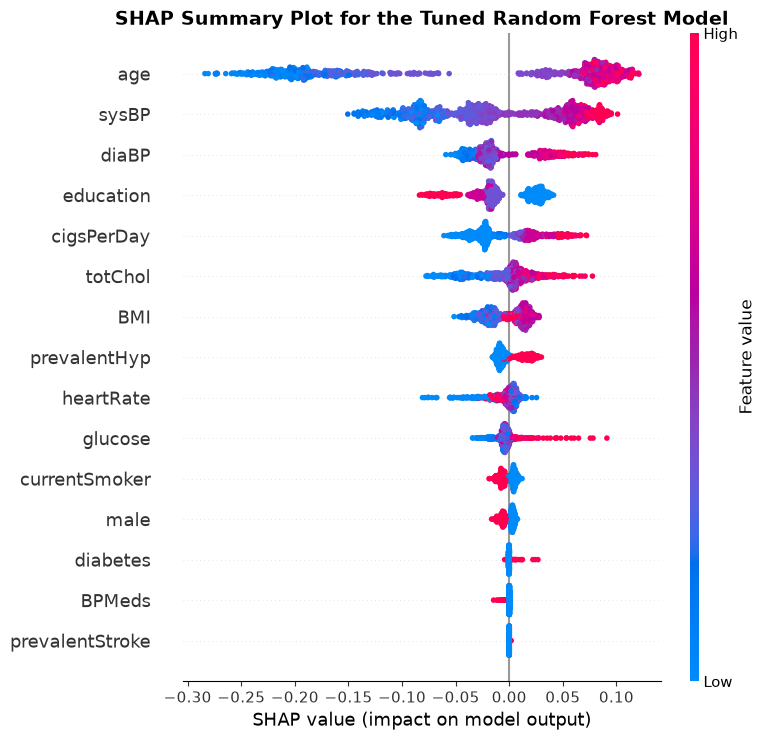

In [13]:
# Extract SHAP values for the positive class (CHD = 1)
rf_shap_positive = random_forest_shap_values[:, :, 1]

# Generate the SHAP summary plot
plt.figure(figsize=(10, 8))

shap.summary_plot(
    rf_shap_positive,
    X_explain_random_forest,
    show=False
)

plt.title(
    "SHAP Summary Plot for the Tuned Random Forest Model",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


The SHAP summary plot provides a global explanation of the tuned Random Forest model by ranking predictor variables according to their overall contribution to coronary heart disease prediction. The predictor variables are arranged from the most influential at the top to the least influential at the bottom based on their average absolute SHAP values.

`age` emerged as the most influential predictor in the tuned Random Forest model. Higher values of `age` generally increased the predicted probability of coronary heart disease, whereas lower values were associated with a reduced predicted risk. This indicates that `age` was the primary determinant of the model's prediction behaviour.

`sysBP` and `diaBP` were also identified as important contributors to the model's predictions. Elevated values of both blood pressure measurements generally shifted the prediction towards coronary heart disease, highlighting the importance of blood pressure in the decision-making process of the Random Forest model.

`education`, `cigsPerDay`, and `totChol` demonstrated moderate influence on the model output. While the contribution of these predictors varied across individual observations, they consistently played meaningful roles in determining the predicted disease risk.

Predictors including `BMI`, `prevalentHyp`, `heartRate`, `glucose`, `currentSmoker`, `male`, `diabetes`, `BPMeds`, and `prevalentStroke` exhibited relatively smaller SHAP values, indicating that they contributed less to the overall prediction behaviour of the tuned Random Forest model. Most of their SHAP values were concentrated around zero, suggesting limited influence for the majority of observations.

Overall, the SHAP analysis indicates that the tuned Random Forest model relied primarily on `age`, `sysBP`, `diaBP`, `education`, `cigsPerDay`, and `totChol` when predicting coronary heart disease. The prominence of these variables further supports the clinical relevance and interpretability of the developed Random Forest model.

### **SHAP Summary Plot for the Tuned Logistic Regression Model**

A SHAP summary plot is generated for the tuned Logistic Regression model to provide a global explanation of its prediction behaviour. Unlike the tree-based models, Logistic Regression is interpreted using the SHAP `LinearExplainer`, which quantifies the contribution of each predictor to the model's linear decision function. The summary plot ranks the predictor variables according to their overall importance while illustrating both the magnitude and direction of their influence on coronary heart disease prediction across all observations.

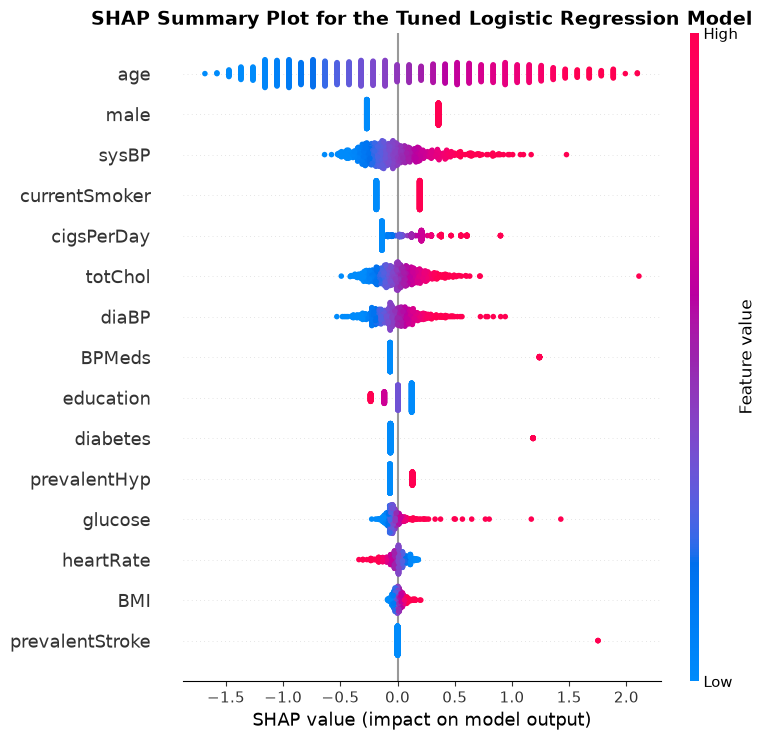

In [14]:
# Generate the SHAP summary plot for the tuned Logistic Regression model
plt.figure(figsize=(10, 8))

shap.summary_plot(
    logistic_shap_values,
    X_explain_logistic,
    show=False
)

plt.title(
    "SHAP Summary Plot for the Tuned Logistic Regression Model",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


The SHAP summary plot provides a global explanation of the tuned Logistic Regression model by ranking predictor variables according to their overall contribution to coronary heart disease prediction. The predictor variables are arranged from the most influential at the top to the least influential at the bottom based on their average absolute SHAP values.

`age` emerged as the most influential predictor in the tuned Logistic Regression model. Higher values of `age` generally increased the predicted probability of coronary heart disease, whereas lower values reduced the predicted risk. This indicates that `age` exerted the strongest influence on the model's decision-making process.

`male` and `sysBP` were identified as the next most influential predictors. The model assigned a higher predicted risk to male patients, while increasing values of `sysBP` generally shifted the prediction towards coronary heart disease. These findings demonstrate that both sex and systolic blood pressure played important roles in the linear decision boundary of the Logistic Regression model.

`currentSmoker`, `cigsPerDay`, `totChol`, and `diaBP` also contributed meaningfully to the model's predictions. Higher values of these variables generally increased the predicted probability of coronary heart disease, although their influence varied across individual observations.

The remaining predictors, including `BPMeds`, `education`, `diabetes`, `prevalentHyp`, `glucose`, `heartRate`, `BMI`, and `prevalentStroke`, exhibited comparatively smaller SHAP values for most observations. This suggests that these variables had relatively limited influence on the overall prediction behaviour of the tuned Logistic Regression model.

Overall, the SHAP analysis indicates that the tuned Logistic Regression model relied primarily on `age`, `male`, `sysBP`, `currentSmoker`, `cigsPerDay`, `totChol`, and `diaBP` when predicting coronary heart disease. The prominence of these established cardiovascular risk factors further supports the interpretability and clinical relevance of the developed Logistic Regression model.

### **Local Explainability Using SHAP**

While SHAP summary plots provide a global understanding of feature importance across the entire dataset, local explanations focus on individual predictions. In this section, SHAP is used to explain the prediction for a single patient by illustrating how each predictor contributes positively or negatively towards the final prediction. This enables a patient-specific interpretation of the developed machine learning model, thereby improving transparency and supporting clinical decision-making.

#### **SHAP Waterfall Plot for an Individual Prediction**

A SHAP waterfall plot is generated to explain the prediction of an individual patient using the tuned XGBoost model. The plot illustrates how the prediction begins from the model's baseline expectation and is subsequently increased or decreased by the contribution of each predictor variable until the final prediction is obtained. Features with larger SHAP values exert greater influence on the prediction than those with smaller contributions.

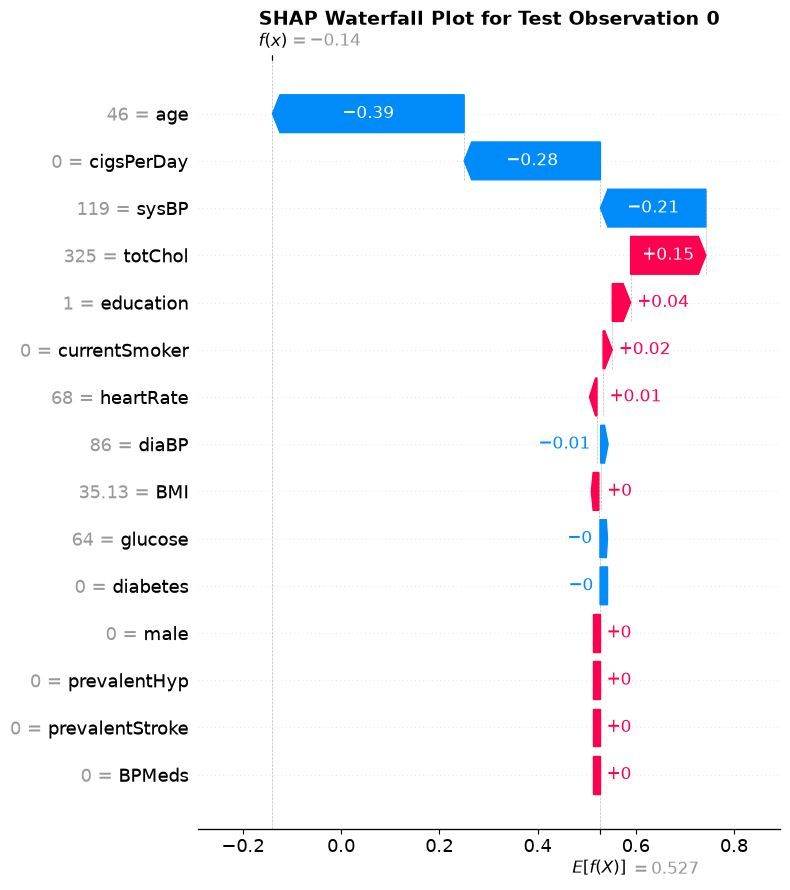

In [15]:
# Select the patient to explain
patient_index = 0

# Generate the SHAP waterfall plot
plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    xgboost_shap_values[patient_index],
    max_display=15,
    show=False
)

plt.title(
    f"SHAP Waterfall Plot for Test Observation {patient_index}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

The SHAP waterfall plot provides a local explanation of the prediction generated by the tuned XGBoost model for a single test observation. The prediction begins from the model's baseline output and is subsequently adjusted by the contribution of each predictor until the final prediction is obtained.

For this observation, `age` made the largest negative contribution to the prediction, reducing the model output by approximately 0.39. Similarly, `cigsPerDay` and `sysBP` further decreased the predicted probability of coronary heart disease by approximately 0.28 and 0.21, respectively. These variables collectively exerted the greatest influence in lowering the predicted risk for this individual.

Conversely, `totChol` provided the largest positive contribution, increasing the model output by approximately 0.15. Smaller positive contributions were also observed from `education`, `currentSmoker`, and `heartRate`, although their effects were considerably weaker than those of the leading predictors.

The remaining variables, including `diaBP`, `BMI`, `glucose`, `diabetes`, `male`, `prevalentHyp`, `prevalentStroke`, and `BPMeds`, contributed only marginally to the final prediction, with SHAP values close to zero. This indicates that these predictors had minimal influence on the prediction for this particular patient.

Overall, the waterfall plot demonstrates that the prediction for this individual was primarily determined by the combined effects of `age`, `cigsPerDay`, `sysBP`, and `totChol`. The opposing contributions of these variables illustrate how SHAP decomposes an individual prediction into interpretable feature-level effects, thereby improving the transparency of the developed coronary heart disease prediction model.

### **SHAP Force Plot for an Individual Prediction**

A SHAP force plot is generated to provide an alternative local explanation of the prediction for the selected test observation. Unlike the waterfall plot, the force plot visualizes how individual predictor variables either increase or decrease the model output relative to the baseline prediction. Features pushing the prediction towards coronary heart disease are displayed in one direction, whereas features reducing the prediction are displayed in the opposite direction, thereby providing an intuitive representation of the model's decision-making process for an individual patient.

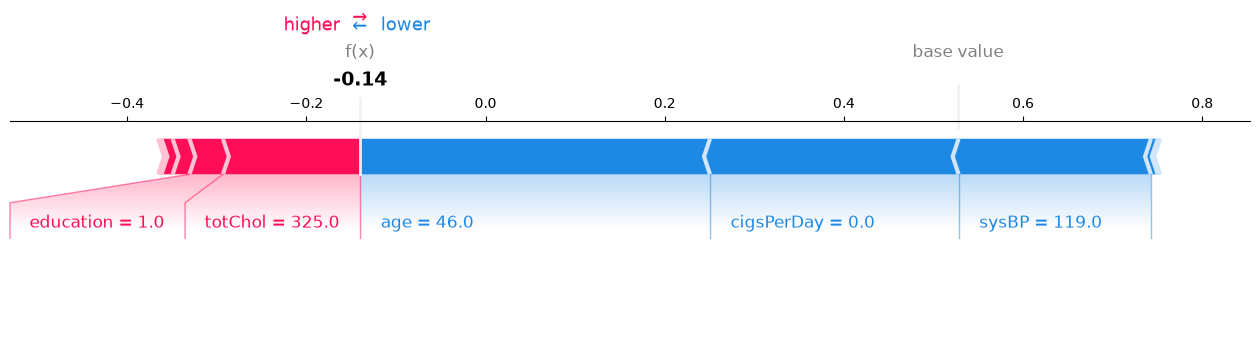

In [16]:
# Enable SHAP visualisation
shap.initjs()

# Generate the SHAP force plot for the selected observation
shap.plots.force(
    xgboost_shap_values[patient_index],
    matplotlib=True,
    figsize=(16, 3),
    show=True
)


The SHAP force plot provides a local explanation of the tuned XGBoost model by illustrating how individual predictor variables influence the prediction for the selected test observation relative to the model's baseline output.

The baseline prediction represents the average model output across the dataset. For this observation, the combined influence of the predictor variables shifted the model output from the baseline value of approximately 0.53 to a final output of approximately -0.14, indicating that the model predicted a relatively low likelihood of coronary heart disease for this individual.

Among the predictors, `age`, `cigsPerDay`, and `sysBP` exerted the strongest influence in reducing the model output, thereby pushing the prediction towards a lower risk of coronary heart disease. These variables collectively contributed most to the decrease from the baseline prediction.

Conversely, `totChol` and `education` increased the model output and partially offset the negative contributions of the other predictors. However, their combined positive influence was insufficient to outweigh the stronger negative contributions of `age`, `cigsPerDay`, and `sysBP`.

Overall, the SHAP force plot demonstrates how the tuned XGBoost model combines the individual effects of multiple clinical and demographic variables to generate a patient-specific prediction. The visualization complements the waterfall plot by providing an intuitive representation of the competing positive and negative feature contributions that determine the final model output.

### **Local Explainability Using LIME**

LIME (Local Interpretable Model-agnostic Explanations) is applied to provide an additional local interpretation of the prediction generated for the selected test observation. Unlike SHAP, which assigns contribution values based on the model’s expected output, LIME approximates the behaviour of the complex model around a specific observation using a simpler interpretable model. This enables the identification of the predictor conditions that locally increase or decrease the likelihood of coronary heart disease.

#### **LIME Explainer Initialisation**

The LIME tabular explainer is initialised using the original training dataset because the tuned XGBoost model was trained on unscaled predictor variables. The feature names and class labels are supplied to ensure that the resulting explanation is presented in a clear and clinically meaningful format.

In [17]:
# Create the LIME tabular explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.to_numpy(),
    feature_names=feature_names,
    class_names=["No CHD", "CHD"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

print("LIME explainer initialised successfully.")

LIME explainer initialised successfully.


### **LIME Explanation for an Individual Prediction**

A LIME explanation is generated for the same test observation previously analysed using SHAP. The tuned XGBoost pipeline is used to obtain class probabilities, ensuring that the explanation reflects the complete prediction workflow. The explanation identifies the feature conditions that locally support or oppose the prediction of coronary heart disease for the selected patient.

In [18]:
# Select the patient observation
patient_data = X_test.iloc[patient_index].to_numpy()

# Generate the LIME explanation
lime_explanation = lime_explainer.explain_instance(
    data_row=patient_data,
    predict_fn=xgboost.predict_proba,
    num_features=len(feature_names),
    top_labels=1
)

# Display the predicted class probabilities
predicted_probabilities = xgboost.predict_proba(
    X_test.iloc[[patient_index]]
)[0]

print(f"Test observation: {patient_index}")
print(f"Probability of No CHD: {predicted_probabilities[0]:.4f}")
print(f"Probability of CHD: {predicted_probabilities[1]:.4f}")
print(f"Predicted class: {xgboost.predict(X_test.iloc[[patient_index]])[0]}")

Test observation: 0
Probability of No CHD: 0.5349
Probability of CHD: 0.4651
Predicted class: 0


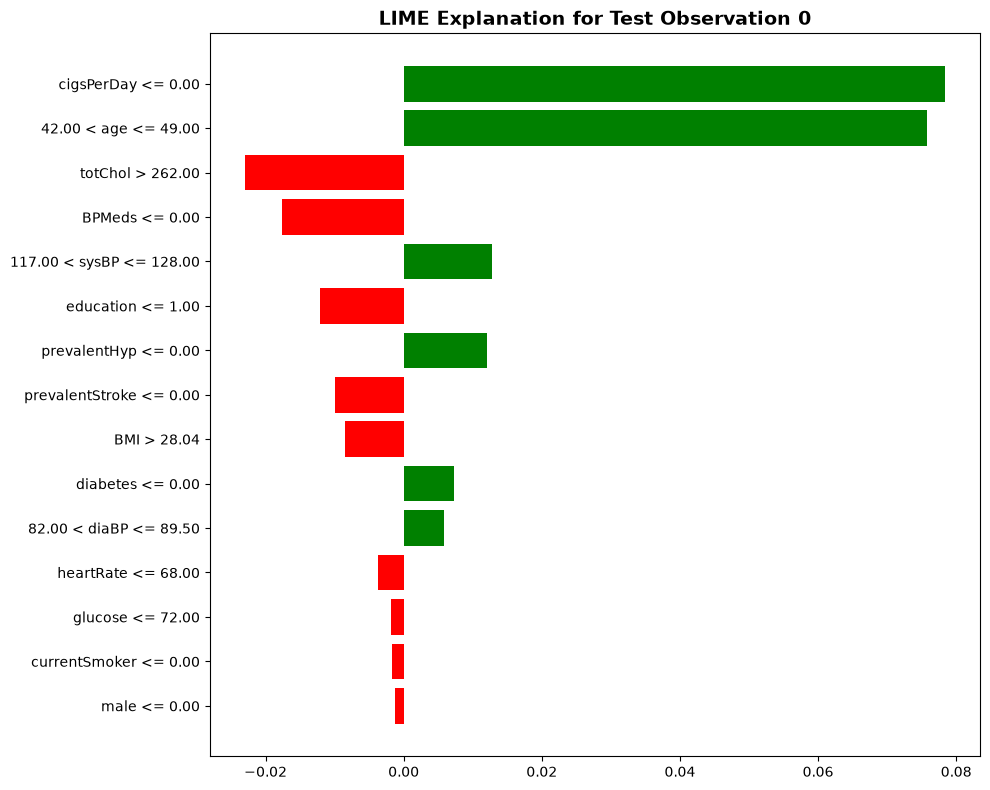

In [19]:
# Identify the predicted class
predicted_class = int(
    xgboost.predict(X_test.iloc[[patient_index]])[0]
)

# Generate the LIME explanation plot
lime_figure = lime_explanation.as_pyplot_figure(
    label=predicted_class
)

lime_figure.set_size_inches(10, 8)

plt.title(
    f"LIME Explanation for Test Observation {patient_index}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

The LIME explanation provides a local interpretation of the tuned XGBoost model by approximating its behaviour around the selected test observation using an interpretable linear model. The plot illustrates the predictor conditions that either increase or decrease the model's prediction for coronary heart disease.

For this observation, `cigsPerDay <= 0.00` and `42.00 < age <= 49.00` made the largest positive contributions towards the predicted class. These feature conditions exerted the strongest influence on the local surrogate model, indicating that they were the most important factors in explaining the prediction for this individual.

Conversely, `totChol > 262.00`, `BPMeds <= 0.00`, and `education <= 1.00` contributed in the opposite direction by reducing the local prediction. Smaller opposing contributions were also observed from `prevalentStroke <= 0.00`, `BMI > 28.04`, `heartRate <= 68.00`, `glucose <= 72.00`, `currentSmoker <= 0.00`, and `male <= 0.00`.

Moderate positive contributions were provided by `117.00 < sysBP <= 128.00`, `prevalentHyp <= 0.00`, `diabetes <= 0.00`, and `82.00 < diaBP <= 89.50`, although their influence was considerably smaller than that of `cigsPerDay` and `age`.

Overall, the LIME explanation demonstrates that the prediction for this individual was primarily influenced by a small subset of clinical variables rather than all available predictors. Furthermore, the agreement between the LIME and SHAP explanations, particularly regarding the importance of `age`, `cigsPerDay`, `totChol`, and `sysBP`, enhances confidence in the transparency and reliability of the developed coronary heart disease prediction model.

## **Overall Explainability Summary**

The explainability analyses demonstrated that both SHAP and LIME effectively improved the transparency of the developed coronary heart disease prediction models by providing global and local interpretations of their prediction behaviour. SHAP identified the overall importance of predictor variables across the entire testing dataset, whereas LIME provided patient-specific explanations by approximating the model locally around an individual observation.

Across the three tuned machine learning models, `age` consistently emerged as the most influential predictor of coronary heart disease. Other clinically important variables, including `sysBP`, `cigsPerDay`, `totChol`, and `diaBP`, also exhibited substantial contributions to the prediction process, although their relative importance varied slightly among the different algorithms. These findings are consistent with established cardiovascular risk factors and demonstrate that the developed models learned clinically meaningful relationships from the data.

The local explanations further illustrated how individual predictor variables collectively influenced patient-level predictions. Both the SHAP waterfall and force plots decomposed the model output into feature-specific contributions, while the LIME explanation independently identified similar influential predictors for the selected observation. The agreement between SHAP and LIME enhances confidence in the reliability and consistency of the explainability results.

Overall, the explainability analyses demonstrate that the developed machine learning models are not only capable of accurately predicting coronary heart disease but are also sufficiently transparent to support interpretation of both global model behaviour and individual patient predictions. Such interpretability is particularly important in healthcare applications, where understanding the rationale behind model predictions is essential for promoting clinician trust and supporting informed decision-making.

## **Conclusion**

This notebook applied SHAP and LIME to explain the prediction behaviour of the tuned machine learning models developed for coronary heart disease prediction. SHAP provided both global and local explanations by quantifying the contribution of individual predictor variables to model predictions, while LIME complemented these findings through interpretable local surrogate models for individual observations.

The explainability results consistently identified clinically relevant predictors, particularly `age`, `sysBP`, `cigsPerDay`, `totChol`, and `diaBP`, as the principal factors influencing coronary heart disease prediction. Furthermore, the consistency observed between SHAP and LIME demonstrates that the developed models produce interpretable and reliable predictions rather than functioning as opaque black-box systems.

By combining predictive performance with robust explainability techniques, the developed models provide an interpretable decision-support framework that has the potential to assist healthcare professionals in understanding the factors contributing to coronary heart disease risk while promoting transparency and trust in machine learning-based clinical decision support systems.

**Next Phase:** Final Model Saving and Deployment Preparation